In [1]:
from dspeed.vis import WaveformBrowser

import os
import yaml
import numpy as np

from pytools4scarf import dataloader

/mnt/atlas02/users/leoli/.conda/envs/leolienv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Inputs
pNNrNNN = "p05/r060"
raw_dir = f"/mnt/atlas01/projects/scarf/data/sp01/prodenv/ref-raw/generated/tier/raw/phy/{pNNrNNN}"
dsp_dir = f"/mnt/atlas01/users/vogl/scarf/sp01/data/dsp_v9-0/phy/{pNNrNNN}"
evt_dir = f"/mnt/atlas01/users/vogl/scarf/sp01/data/evt_v9-0/phy/{pNNrNNN}"
hpge_dsp_config_file = "/mnt/atlas01/users/vogl/scarf/sp01/metadata/dsp/ged_dsp_conf.yaml"
dsp_database_file = "/mnt/atlas01/users/vogl/scarf/sp01/metadata/dsp/dsp_database_general.yaml"


channels = [f"ch{str(n).zfill(3)}" for n in range(1, 11)]
hpge_channels = ["ch001", "ch002"]
sipm_channels = [f"ch{str(n).zfill(3)}" for n in range(3, 10)]
dsp_groups = [ch+"/dsp" for ch in hpge_channels]
evt_groups = [ch+"/evt" for ch in channels]
all_raw_files = sorted(os.listdir(raw_dir))

In [3]:
browser = WaveformBrowser(all_raw_files, "ch002/raw", base_path=raw_dir, lines=["waveform_presummed"])

(0, 1)

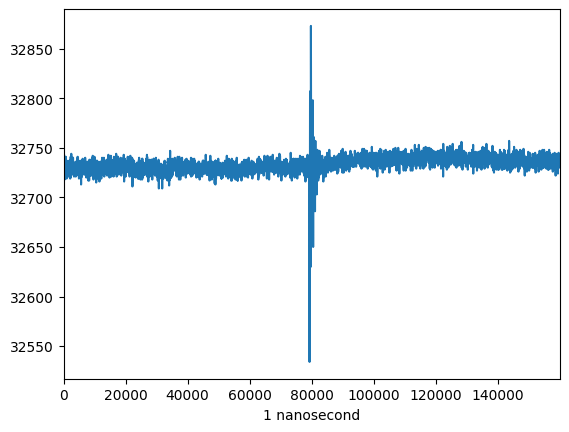

In [4]:
browser.draw_next()

In [5]:
with open(dsp_database_file) as f:
    db = yaml.safe_load(f)

all_raw_files = sorted(os.listdir(raw_dir))
evt_dfs = dataloader.load_lh5_files(["ch001/evt", "ch002/evt"], 
                                    [os.path.join(evt_dir, f) for f in sorted(os.listdir(evt_dir))], 
                                    hpge_channels, library="ak")

In [6]:
e_mask = (np.array(evt_dfs["ch002"].trapEftp_fix_cal)>1839) & (np.array(evt_dfs["ch002"].trapEftp_fix_cal)<2239)

mask = np.array(evt_dfs["ch002"].is_valid_waveform & e_mask & (~evt_dfs["ch002"].is_lar_vetoed) & (~evt_dfs["ch002"].is_muon))

roi_browser_long = WaveformBrowser(all_raw_files, "ch002/raw", base_path=raw_dir, dsp_config=hpge_dsp_config_file, 
                                    database=db["ch002"], entry_mask=mask,
                                    lines=["waveform_presummed"]
                                    )
roi_browser_short = WaveformBrowser(all_raw_files, "ch002/raw", base_path=raw_dir, dsp_config=hpge_dsp_config_file, 
                                    database=db["ch002"], entry_mask=mask,
                                    lines=["waveform_windowed"]
                                    )

(0, 1)

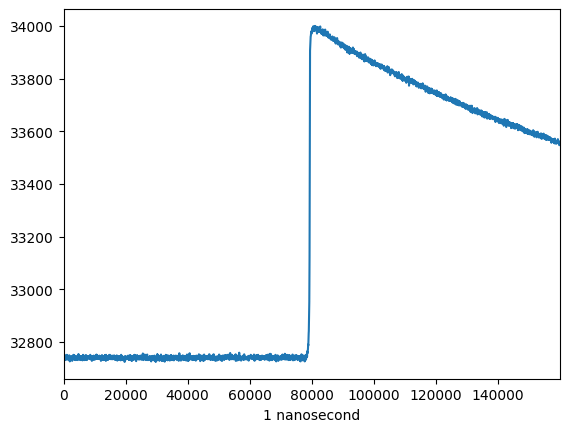

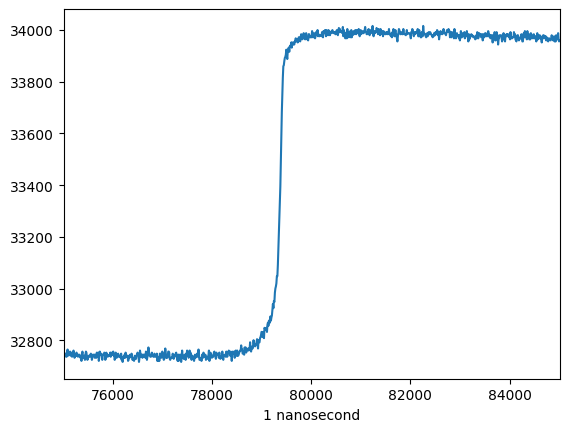

In [7]:
roi_browser_long.draw_next()
roi_browser_short.draw_next()

In [8]:
dsp_dfs = dataloader.load_data(dsp_dir, dsp_groups, hpge_channels)

AttributeError: module 'pytools4scarf.dataloader' has no attribute 'load_data'

In [ ]:
# check why trapEftp is nan
e_mask = np.isnan(dsp_dfs["ch002"].trapEftp)

nan_browser = WaveformBrowser(all_raw_files, "ch002/raw", base_path=raw_dir, dsp_config=hpge_dsp_config_file, 
                                    database=db["ch002"], entry_mask=e_mask,
                                    lines=["wf_blsub", "wf_trap", "tp_0_atrap", "trapEftp"],
                                    legend=["trapEftp={trapEftp}"]
                                    )

(11, 12)

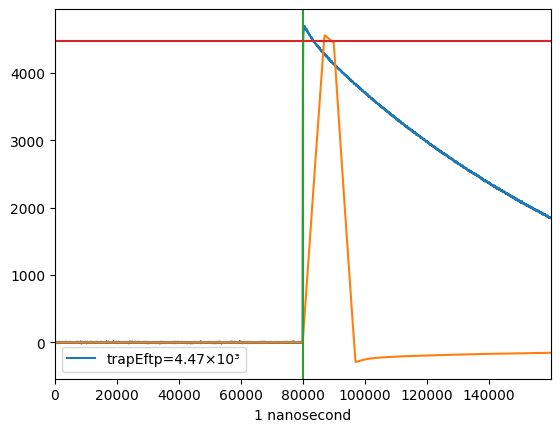

In [ ]:
nan_browser.draw_next()

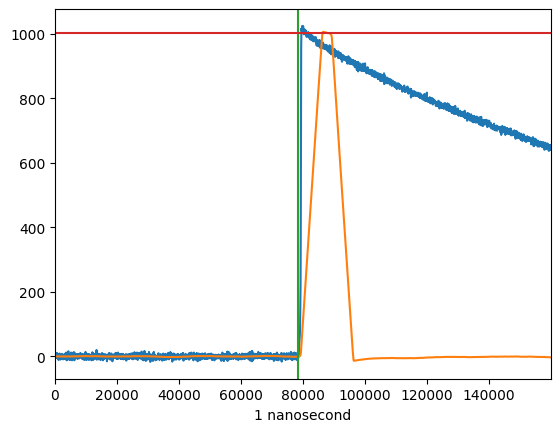

In [ ]:
nan_browser.draw_entry(66)

In [ ]:
qc_mask = evt_dfs["ch002"].is_valid_waveform
e_mask = (evt_dfs["ch002"].trapEftp_cal>1839) & (evt_dfs["ch002"].trapEftp_cal<2239)
low_aoe = ~evt_dfs["ch002"].Amaxmw_o_E_Low_Cut

selection_browser = WaveformBrowser(all_raw_files, "ch002/raw", base_path=raw_dir, dsp_config=hpge_dsp_config_file, 
                                    database=db["ch002"], entry_mask=qc_mask&e_mask&~is_muon&low_aoe,
                                    #lines=["waveform_presummed"],
                                    lines=["waveform_windowed"],
                                    #legend="ts={timestamp:f}"
                                    #legend="tail_rms={tail_rms}"
                                    )

(16, 17)

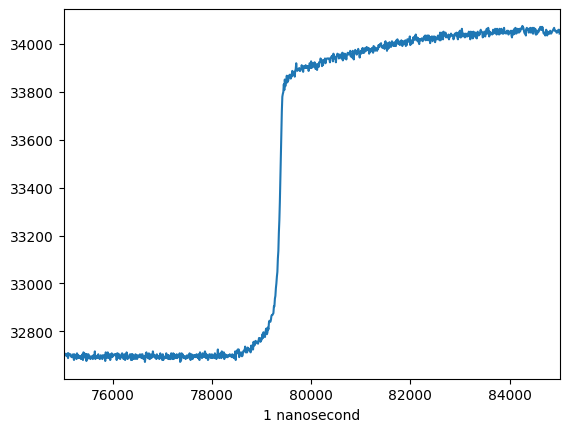

In [ ]:
selection_browser.draw_next()

In [ ]:
qc_mask = evt_dfs["ch002"].is_valid_waveform
e_mask = (evt_dfs["ch002"].trapEftp_cal>1839) & (evt_dfs["ch002"].trapEftp_cal<2239)
sse_aoe = evt_dfs["ch002"].Amaxmw_o_E_Double_Sided_Cut

sse_browser = WaveformBrowser(all_raw_files, "ch002/raw", base_path=raw_dir, dsp_config=hpge_dsp_config_file, 
                                    database=db["ch002"], entry_mask=qc_mask&e_mask&~is_muon&sse_aoe,
                                    lines=["waveform_windowed"],
                                    )

(0, 10)

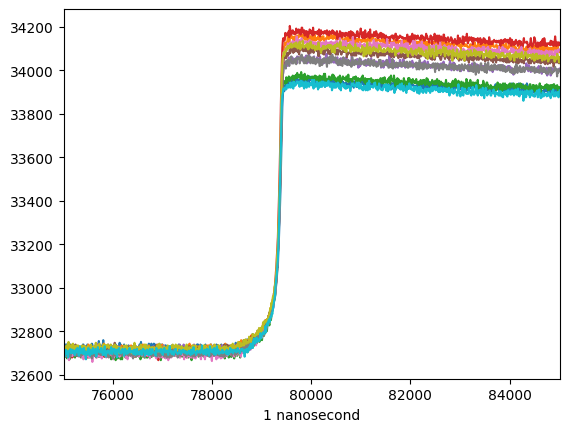

In [ ]:
sse_browser.draw_next(n_wfs=10)

(10, 11)

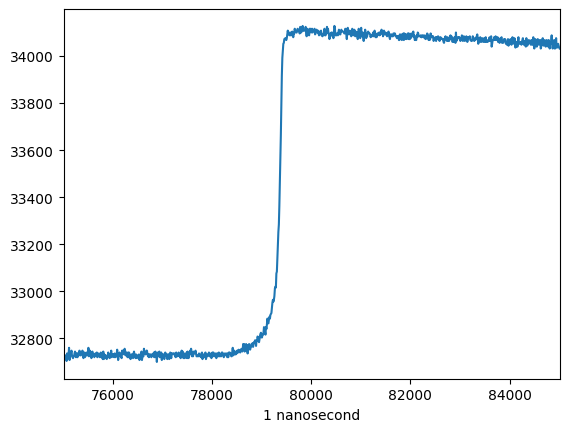

In [ ]:
#sse_browser.draw_entry(43)
sse_browser.draw_next()

In [ ]:
qc_mask = evt_dfs["ch002"].is_valid_waveform
e_mask = (evt_dfs["ch002"].trapEftp_cal>1839) & (evt_dfs["ch002"].trapEftp_cal<2239)
large_aoe = (evt_dfs["ch002"].Amaxmw_o_E_Classifier > 3) & (evt_dfs["ch002"].Amaxmw_o_E_Classifier < 8)

large_aoe_browser = WaveformBrowser(all_raw_files, "ch002/raw", base_path=raw_dir, dsp_config=hpge_dsp_config_file, 
                                    database=db["ch002"], entry_mask=qc_mask&e_mask&~is_muon&large_aoe,
                                    lines=["waveform_windowed"],
                                    )

(0, 1)

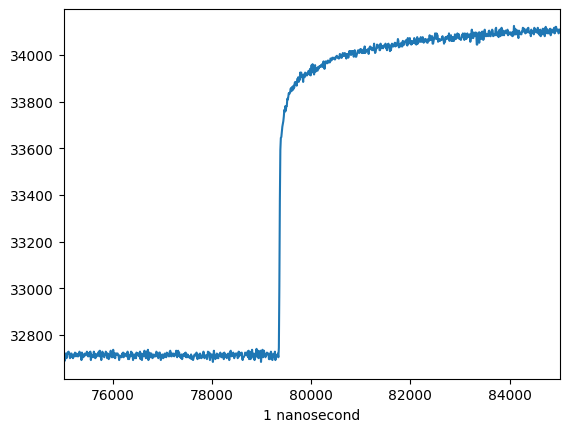

In [ ]:
large_aoe_browser.draw_next(n_wfs=1)